In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
path1 = r"H:\Python\analise_dados\atividade6\Tabela5-sem_emprego_2012.csv"
path2 = r"H:\Python\analise_dados\atividade6\Tabela5-sem_emprego_2026.csv"
path3 = r"H:\Python\analise_dados\atividade6\Tabela 1.1.1.xls"

In [125]:
tab2012 = pd.read_csv(path1, sep=";", encoding='UTF-8', decimal=",")

In [126]:
tab2012 = tab2012.rename(columns={"Desocupados - homens (2012 T1)" : "homens_2012", "Desocupados - mulheres (2012 T1)" : "mulheres_2012"})
tab2012

,Sigla,Código,Estado,homens_2012,mulheres_2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [127]:
tab2026 = pd.read_csv(path2, sep=";", encoding='UTF-8', decimal=",")

In [128]:
tab2026 = tab2026.rename(columns={"Desocupados - homens (2026 T1)" : "homens_2026", "Desocupados - mulheres (2026 T1)" : "mulheres_2026"})
tab2026

,Sigla,Código,Estado,homens_2026,mulheres_2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [129]:
comp = tab2012.merge(tab2026, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [130]:
tabHoras = pd.read_excel(path3, engine="xlrd")

In [131]:

tabHoras = tabHoras.iloc[8:40].copy()
tabHoras.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
tabHoras = tabHoras.reset_index(drop=True)

# horas são número, não texto
for col in tabHoras.columns[1:]:
    tabHoras[col] = pd.to_numeric(tabHoras[col], errors="coerce")

tabHoras

,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
1,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
2,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
3,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
4,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
5,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
6,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
7,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
8,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716
9,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


In [132]:
tabHoras = tabHoras.rename(columns={"uf_regiao" : "Estado"})

In [133]:
regioesL = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

tabHoras = tabHoras[~tabHoras["Estado"].isin(regioesL)]

In [134]:
tabHoras

,Estado,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
1,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
2,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
3,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
4,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
5,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
6,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
7,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
9,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589
10,Piauí,17.960366,16.948094,18.231789,12.258324,11.204814,20.494063,23.695440
11,Ceará,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274


In [135]:
comp = tabHoras.merge(comp, on=["Estado"], how="left")

In [136]:
comp

,Estado,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda,Sigla,Código,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410,RO,11,43.4,56.6,33.0,67.0
1,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754,AC,12,45.3,54.7,53.2,46.8
2,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986,AM,13,47.5,52.5,46.8,53.2
3,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244,RR,14,41.8,58.2,43.4,56.6
4,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144,PA,15,43.2,56.8,48.3,51.7
5,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487,AP,16,48.1,51.9,51.1,48.9
6,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399,TO,17,55.3,44.7,46.2,53.8
7,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589,MA,21,47.2,52.8,49.1,50.9
8,Piauí,17.960366,16.948094,18.231789,12.258324,11.204814,20.494063,23.695440,PI,22,51.2,48.8,55.1,44.9
9,Ceará,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274,CE,23,51.1,48.9,52.7,47.3


In [146]:
anos = [c for c in comp.columns if str(c)]

ordem = comp.sort_values("mulheres_2026")["Estado"]

longo = comp.melt(
    id_vars=["Estado", "Sigla"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

In [147]:
longo.head()

,Estado,Sigla,Ano,Participacao_mulheres
0,Rondônia,RO,2012 T1,56.6
1,Acre,AC,2012 T1,54.7
2,Amazonas,AM,2012 T1,52.5
3,Roraima,RR,2012 T1,58.2
4,Pará,PA,2012 T1,56.8


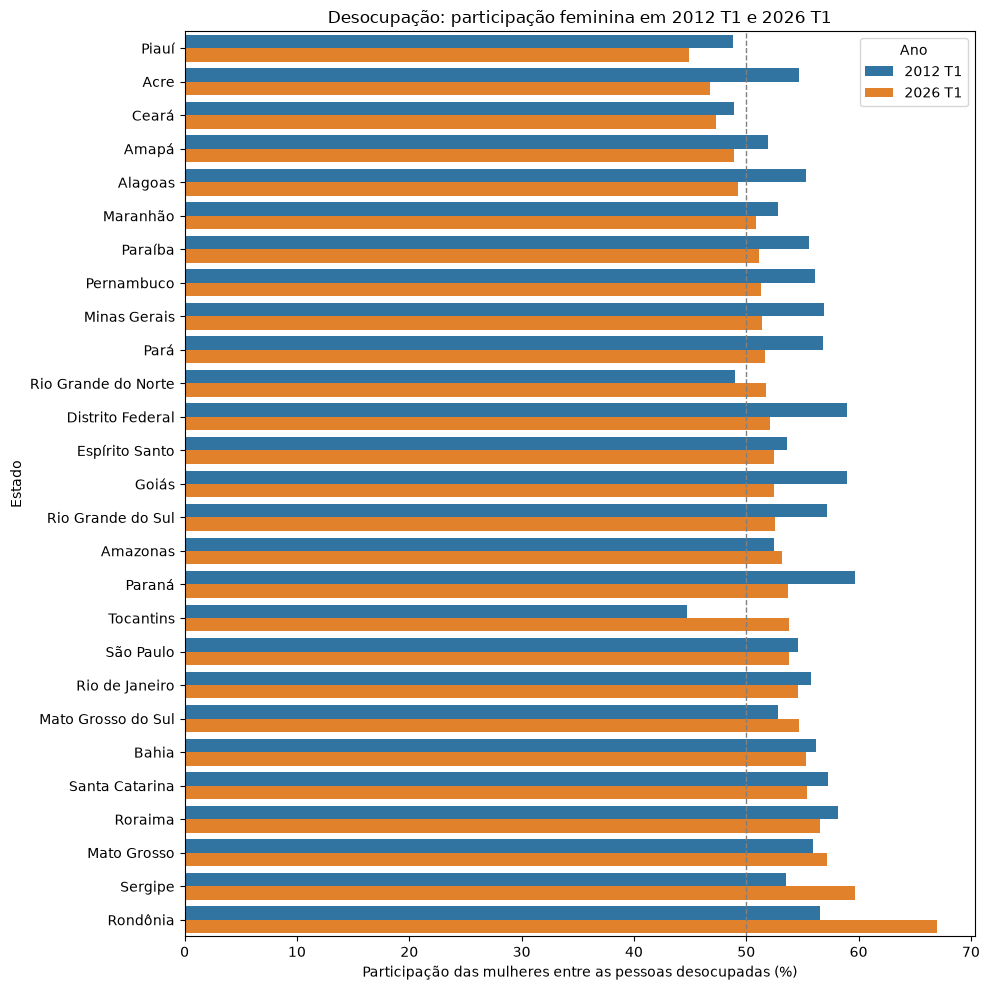

In [149]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="gray", linestyle="--", linewidth=1) # MUDE A COR
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("Estado")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Ano")
fig.tight_layout()
plt.show()